# Computational Thermofluid Dynamics - Chapter 1

Technical University of Munich, Professur für Thermofluiddynamik - Pr. Polifke

Created: 04/2024 | J. Yao, N. Garcia, G. Varillon
Modification: 10/2024 | A. Kheles

==============================================================================================

# Exercise 1
In this exercise we introduced partial differential equations (PDEs) in the context of transport equations. We have identified particularly three types of equations in which linear PDEs are classified: parabolic, hyperbolic or elliptic. Now, we propose to use Python as the numerical tool to write and visualize some analytical solutions that correspond to some specific cases of these equations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from matplotlib.animation import FuncAnimation
from IPython.display import HTML # to display the animations in jupyter

## Stage 1: Fourier Expression
We consider the function $\phi(x)$ defined as:
$$
\phi(x)=   \left\{
\begin{array}{ll}
      x & 0<x<=1 \\
      2-x & 1<x<=2 \\
      0 & 2<x<L \\
\end{array} 
\right.  
$$
Hint: use sympy to define $x$ as a symbol

In [2]:
# Write the code for stage 1 here:
# Hint: use Piecewise() method!
x = sp.symbols('x')
phi = lambda L: sp.Piecewise((x, sp.And(x <= 1, x>0)), (2 - x, sp.And( 1 < x,x <= 2)), (0,  sp.And(2 < x, x < L)))
L = 10
phi_l = phi(L)
phi_l

Piecewise((x, (x <= 1) & (x > 0)), (2 - x, (x <= 2) & (x > 1)), (0, (x > 2) & (x < 10)))

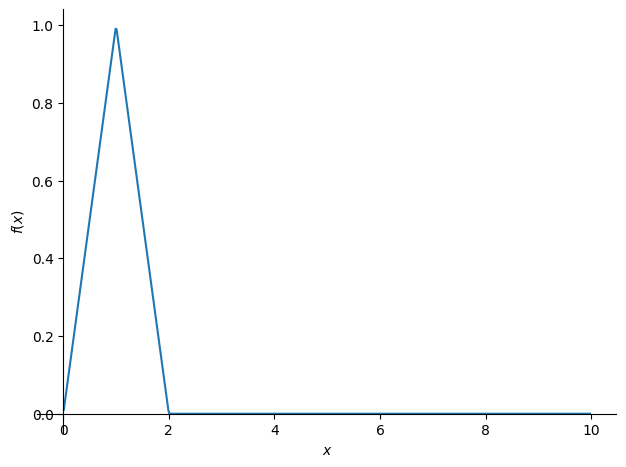

In [3]:
sp.plot(phi_l)

Express $\phi(x)$ as a Fourier sine expansion as:
$$
\phi(x) = \tilde\phi(x) = \sum_{m=1}^Na_m\sin\frac{m\pi x}{L}
$$
$$
a_m = \frac{2}{L}\int_0^L\phi(x)\sin\frac{m\pi x}{L}\,dx
$$
where $N$ is a number high enough to satisfy a good approximation $\tilde\phi(x)$ (it is recommended $N>100$)

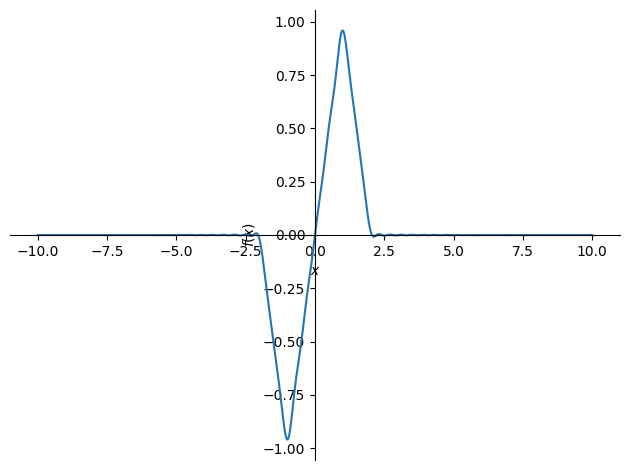

In [4]:
# Write here your code for the Fourier expansion
n = 50
m = sp.symbols('m')
a_m =  2 / L * sp.integrate(phi_l * sp.sin(m * np.pi * x / L), (x, 0, L))
phi_l_fourier = sp.summation(a_m * sp.sin(m * np.pi * x / L), (m, 0, n))
sp.plot(phi_l_fourier)

In [5]:
f = sp.lambdify(x, phi_l_fourier)
f(2)

np.float64(0.020531615538095318)

## Stage 2: Convection
The 1D convection equation reads:
$$
\frac{\partial\phi}{\partial t} + v_x\frac{\partial\phi}{\partial x}=0
$$
Any function $\phi$ with argument $x-v_xt$ is a solution of this equation. \
Replace $\tilde\phi(x)$ by $\tilde\phi(x-v_xt)$ (note that coefficients $a_m$ remains the same) for one value of $v_x$ and several times $t_{i+1}=t_i+\Delta t$ for small $\Delta t$. For each time $t$ plot the function $\tilde\phi(x-v_xt)$ and create animation

In [6]:
# Write here the code
v, t = sp.symbols('v, t')
phi_subs = phi_l_fourier.subs({x: x - v * t})



Text(0.5, 1.0, 'φ(x, t) evolution')

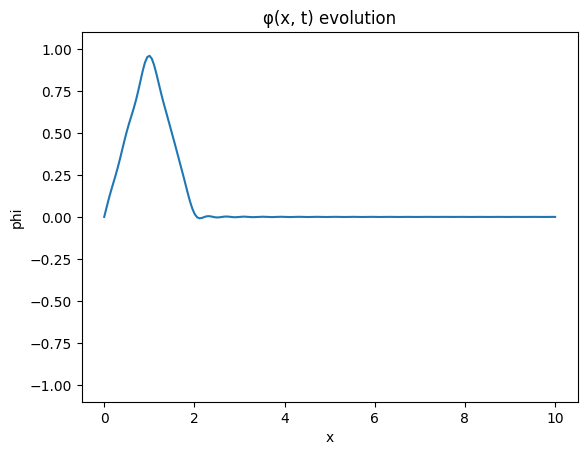

In [7]:
v_x = 0.4
phi_subs_v = phi_subs.subs({v: v_x})
phi_plot_func = sp.lambdify((x, t), phi_subs_v, 'numpy')
t_0 = 0
n_steps = 20
t_values = np.linspace(0, 10, n_steps)

# setup plot
fig, ax = plt.subplots()
x_vals = np.linspace(0, L, 200)
line, = ax.plot(x_vals, phi_plot_func(x_vals, t_0))
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel("x")
ax.set_ylabel("phi")
ax.set_title("φ(x, t) evolution")

In [8]:
def update(frame):
    t_val = t_values[frame]
    y_vals = phi_plot_func(x_vals, t_val)
    line.set_ydata(y_vals)
    ax.set_title(f"φ(x, t={t_val:.2f})")
    return line,

In [9]:
# create animation
ani = FuncAnimation(fig, update, frames=n_steps, interval=100, blit=True)
HTML(ani.to_jshtml())


In [10]:
ani.save("convection.gif", writer="imagemagick", fps=10)

## Stage 3: Diffusion
The 1D diffusion equation reads:
$$
\frac{\partial\phi}{\partial t} - \mathcal{D}\frac{\partial^2\phi}{\partial x^2}=0
$$
The solution of this equation, for homogeneous Dirichlet boundary conditions, is written as
$$
\phi(x)\approx\tilde\phi(x,t)=\sum_{m=1}^Na_me^{-\mathcal{D}(m\pi / L)^2t}\sin\frac{m\pi x}{L} \\
$$
Define the solution of diffusion and make animation

In [11]:
# Write here the code
diff_coeff = 0.05
phi_diff_func = sp.summation(a_m * sp.exp(-diff_coeff * (m * np.pi / L)**2 * t) * sp.sin(m * np.pi * x / L), (m, 0, n))

Text(0.5, 1.0, 'φ(x, t) diffusion evolution')

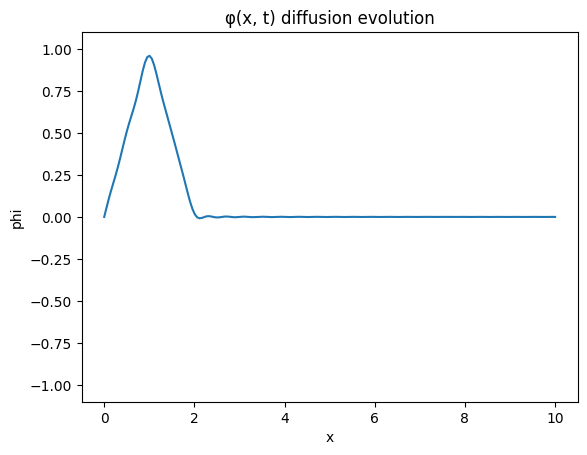

In [12]:
phi_diff_plot_func = sp.lambdify((x, t), phi_diff_func, 'numpy')

# setup plot
fig, ax = plt.subplots()
x_vals = np.linspace(0, L, 200)
line, = ax.plot(x_vals, phi_diff_plot_func(x_vals, t_0))
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel("x")
ax.set_ylabel("phi")
ax.set_title("φ(x, t) diffusion evolution")

In [13]:
def update(frame):
    t_val = t_values[frame]
    y_vals = phi_diff_plot_func(x_vals, t_val)
    line.set_ydata(y_vals)
    ax.set_title(f"φ(x, t={t_val:.2f})")
    return line,

In [14]:
# create animation
ani = FuncAnimation(fig, update, frames=n_steps, interval=100, blit=True)
HTML(ani.to_jshtml())


In [15]:
ani.save("diffusion.gif", writer="imagemagick", fps=10)

## Stage 4: Convection-Diffusion
The 1D convection-diffusion equation reads:
$$
\frac{\partial\phi}{\partial t} + v_x\frac{\partial\phi}{\partial x}- \mathcal{D}\frac{\partial^2\phi}{\partial x^2}=0
$$
Combining the analytical solution of convection and diffusion, the solution for convection-diffusion can be written as:
$$
\phi(x)\approx\tilde\phi(x,t)=\sum_{m=1}^Na_me^{-\mathcal{D}(m\pi / L)^2t}\sin\frac{m\pi (x-v_xt)}{L} \\
$$

In [16]:
# Write here the code
phi_conv_diff = sp.summation(a_m * sp.exp(-diff_coeff * (m * np.pi / L)**2 * t) * sp.sin(m * np.pi * x / L), (m, 0, n))
phi_conv_diff = phi_conv_diff.subs({x: x - v * t})

Text(0.5, 1.0, 'φ(x, t) evolution')

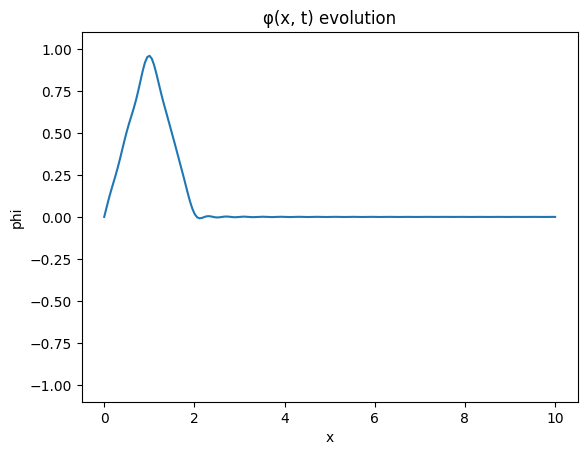

In [17]:
v_x = 0.4
phi_cf_v_sub = phi_conv_diff.subs({v: v_x})
phi_cf_plot_func = sp.lambdify((x, t), phi_cf_v_sub, 'numpy')
t_0 = 0
n_steps = 20
t_values = np.linspace(0, 10, n_steps)

# setup plot
fig, ax = plt.subplots()
x_vals = np.linspace(0, L, 200)
line, = ax.plot(x_vals, phi_plot_func(x_vals, t_0))
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel("x")
ax.set_ylabel("phi")
ax.set_title("φ(x, t) evolution")

In [18]:
def update(frame):
    t_val = t_values[frame]
    y_vals = phi_cf_plot_func(x_vals, t_val)
    line.set_ydata(y_vals)
    ax.set_title(f"φ(x, t={t_val:.2f}) Diffusion-Convection")
    return line,

In [19]:
# create animation
ani = FuncAnimation(fig, update, frames=n_steps, interval=100, blit=True)
HTML(ani.to_jshtml())

In [20]:
ani.save("diffusion_convection.gif", writer="imagemagick", fps=10)

## Stage 5: Error Calculation
In mathematical analysis, the **L2 norm** is a way of measuring the difference between two functions, or between an **actual** function and its **approximation**. For a given function $\phi(x)$, the L2 norm is defined as:
$$\text{L2 norm} = \left( \int_0^L |\phi(x) - \tilde{\phi}(x)|^2 \, dx \right)^{1/2}$$

In the context of comparing an **actual function** and an **approximation** (such as a Fourier series approximation), the L2 norm measures the root mean square error between the two functions. This is crucial when you want to evaluate how well an approximation, like a Fourier series, represents the actual function.

### How to Calculate the L2 Norm:

To compute the L2 norm for an approximation, say $\tilde{\phi}(x)$, compared to the actual function $\phi(x)$, we follow these steps:
1. Evaluate the difference between the two functions pointwise: $\phi(x) - \tilde{\phi}(x)$ (actual minus approximation).
2. Square the difference.
3. Integrate the squared difference over the domain of interest (from 0 to L).
4. Take the square root of the integral result.

In this exercise, you'll compute the L2 norm error between a **piecewise actual function** and its **Fourier approximation**, using numerical techniques.

### Example L2 Calculation for Discrete Points
```python
import numpy as np

actual_value = np.array([1, 2, 3])
predicted_value = np.array([1.1, 2.1, 5 ])

# take square of differences and sum them
l2_norm = np.sum(np.power((actual_value-predicted_value),2))

# take the square root of the sum of squares to obtain the L2 norm
l2_norm = np.sqrt(l2)
print(l2_norm)

In [21]:
# Write your code here!
x_vals = np.linspace(0.001, 9.999, 100)
actual_func = sp.lambdify(x, phi_l, 'numpy')
fourier_func = sp.lambdify(x, phi_l_fourier, 'numpy')


In [22]:
actual_vals = actual_func(x_vals)
approx_vals = fourier_func(x_vals)
l2_norm = np.sum(np.power((actual_vals - approx_vals), 2))
l2_norm

np.float64(0.0018469311695280446)

In [23]:
l2_norm = np.power(l2_norm, 0.5)

In [24]:
l2_norm

np.float64(0.04297593709889343)

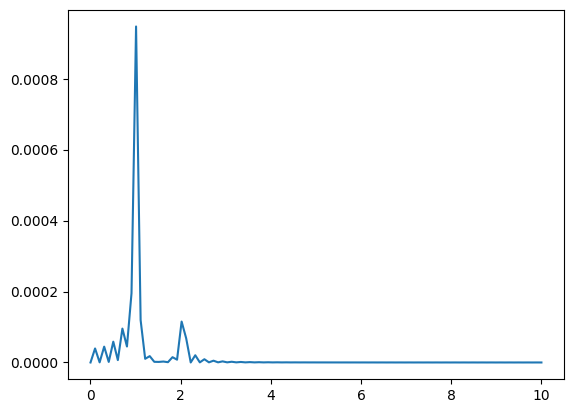

In [25]:
plt.plot(x_vals, np.power((actual_vals - approx_vals), 2))

Plot the influence of number of terms in the Fourier summation on the L2 norm error

In [26]:
sum_terms = np.linspace(50, 99, 10, dtype=int)
fourier_approx_list = [sp.summation(a_m * sp.sin(m * np.pi * x / L), (m, 0, num)) for num in sum_terms]
fourier_func_list = [sp.lambdify(x, fourier_approx, 'numpy') for fourier_approx in fourier_approx_list]
approx_vals = [fourier_func(x_vals) for fourier_func in fourier_func_list]
approx_vals = np.array(approx_vals)
l2_norms = [np.power(np.sum(np.power((actual_vals - approx), 2)), 0.5) for approx in approx_vals]

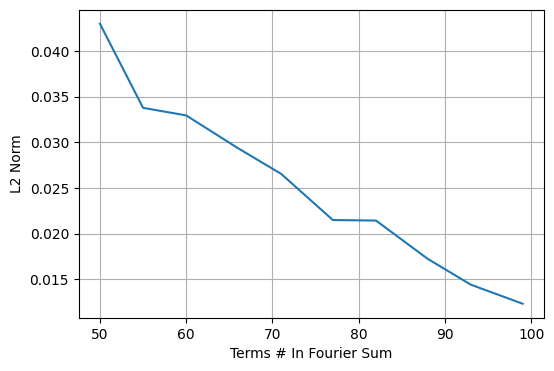

In [28]:
fig = plt.figure(figsize=(6,4))
plt.plot(sum_terms, l2_norms)
plt.grid()
plt.xlabel("Terms # In Fourier Sum")
plt.ylabel("L2 Norm")
plt.show()